In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import joblib
import matplotlib.pyplot as plt

In [2]:
# Load datasets
X_train = np.load("X_train.npy")  # Shape: (41321, 48, 1)
y_train = np.load("y_train.npy")  # Shape: (41321, 4)
X_val   = np.load("X_val.npy")    # Shape: (8759, 48, 1)
y_val   = np.load("y_val.npy")    # Shape: (8759, 4)
X_test  = np.load("X_test.npy")   # Shape: (8872, 48, 1)
y_test  = np.load("y_test.npy")   # Shape: (8872, 4)

# Load scaler
scaler = joblib.load("scaler.pkl")

In [4]:
print("Dataset Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

Dataset Shapes:
X_train: (41321, 24, 1) y_train: (41321, 4)
X_val  : (8759, 24, 1) y_val  : (8759, 4)
X_test : (8872, 24, 1) y_test : (8872, 4)


In [ ]:
# Build RNN model
model = Sequential()

# SimpleRNN layer
model.add(SimpleRNN(
    units=128,  # Need more units for RNN (less expressive per unit)
    input_shape=(X_train.shape[1], X_train.shape[2]),
    return_sequences=False,  # Single RNN layer
    activation='tanh',  # simple RNN uses tanh
    name='simple_rnn_layer'
))

# Dropout - RNN needs more regularization (prone to overfitting)
model.add(Dropout(0.3))  # Higher dropout than LSTM/GRU

# Additional dense layer (RNN benefits from feature transformation)
model.add(Dense(
    units=32,
    activation='relu',
    name='dense_feature'
))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(
    units=y_train.shape[1],  # 4 steps
    activation='linear',
    name='output'
))

# Compile with slightly higher learning rate (RNN needs it)
model.compile(
    optimizer=Adam(learning_rate=0.002),  # Higher LR than LSTM/GRU
    loss='mse',
    metrics=['mae', 'mse']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_layer (SimpleRNN)    │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature (Dense)           │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,900 (81.64 KB)

 Trainable params: 20,900 (81.64 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Callbacks with more patience (RNN Slower)
early_stop = EarlyStopping(
    monitor='val_mae',
    patience=20,  # More patience for RNN
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_rnn_glucose_model.h5',
    monitor='val_mae',
    save_best_only=True,
    verbose=1
)

In [9]:
# Train model
print("\nTraining SimpleRNN for glucose prediction...")
print("Note: RNN may train slower and need more epochs")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,  # More epochs for RNN
    batch_size=32,  # Smaller batch size for RNN stability
    callbacks=[early_stop, checkpoint],
    verbose=1,
    shuffle=True
)


Training SimpleRNN for glucose prediction...
Note: RNN may train slower and need more epochs
Epoch 1/150
1291/1292 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0100 - mae: 0.0665 - mse: 0.0100
Epoch 1: val_mae improved from inf to 0.03407, saving model to best_rnn_glucose_model.h5


1292/1292 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.0099 - mae: 0.0665 - mse: 0.0099 - val_loss: 0.0024 - val_mae: 0.0341 - val_mse: 0.0024
Epoch 2/150
1286/1292 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031 - mae: 0.0403 - mse: 0.0031
Epoch 2: val_mae improved from 0.03407 to 0.03335, saving model to best_rnn_glucose_model.h5


1292/1292 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0031 - mae: 0.0403 - mse: 0.0031 - val_loss: 0.0023 - val_mae: 0.0333 - val_mse: 0.0023
Epoch 3/150
1289/1292 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030 - mae: 0.0398 - mse: 0.0030
Epoch 3: val_mae did not improve from 0.03335
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0030 - mae: 0.0398 - mse: 0.0030 - val_loss: 0.0023 - val_mae: 0.0338 - val_mse: 0.0023
Epoch 4/150
1291/1292 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0030 - mae: 0.0394 - mse: 0.0030
Epoch 4: val_mae improved from 0.03335 to 0.03327, saving model to best_rnn_glucose_model.h5


1292/1292 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0030 - mae: 0.0394 - mse: 0.0030 - val_loss: 0.0023 - val_mae: 0.0333 - val_mse: 0.0023
Epoch 5/150
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0029 - mae: 0.0392 - mse: 0.0029
Epoch 5: val_mae did not improve from 0.03327
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0029 - mae: 0.0392 - mse: 0.0029 - val_loss: 0.0023 - val_mae: 0.0334 - val_mse: 0.0023
Epoch 6/150
1291/1292 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0029 - mae: 0.0390 - mse: 0.0029
Epoch 6: val_mae did not improve from 0.03327
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0029 - mae: 0.0390 - mse: 0.0029 - val_loss: 0.0023 - val_mae: 0.0336 - val_mse: 0.0023
Epoch 7/150
1287/1292 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0111 - mae: 0.0558 - mse: 0.0111
Epoch 7: val_mae did not improve from 0.03327
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0111 - mae: 0.0559 - mse: 0.0111 - val_loss: 0.0114 - val_mae: 0.0849 - val_mse: 0.0

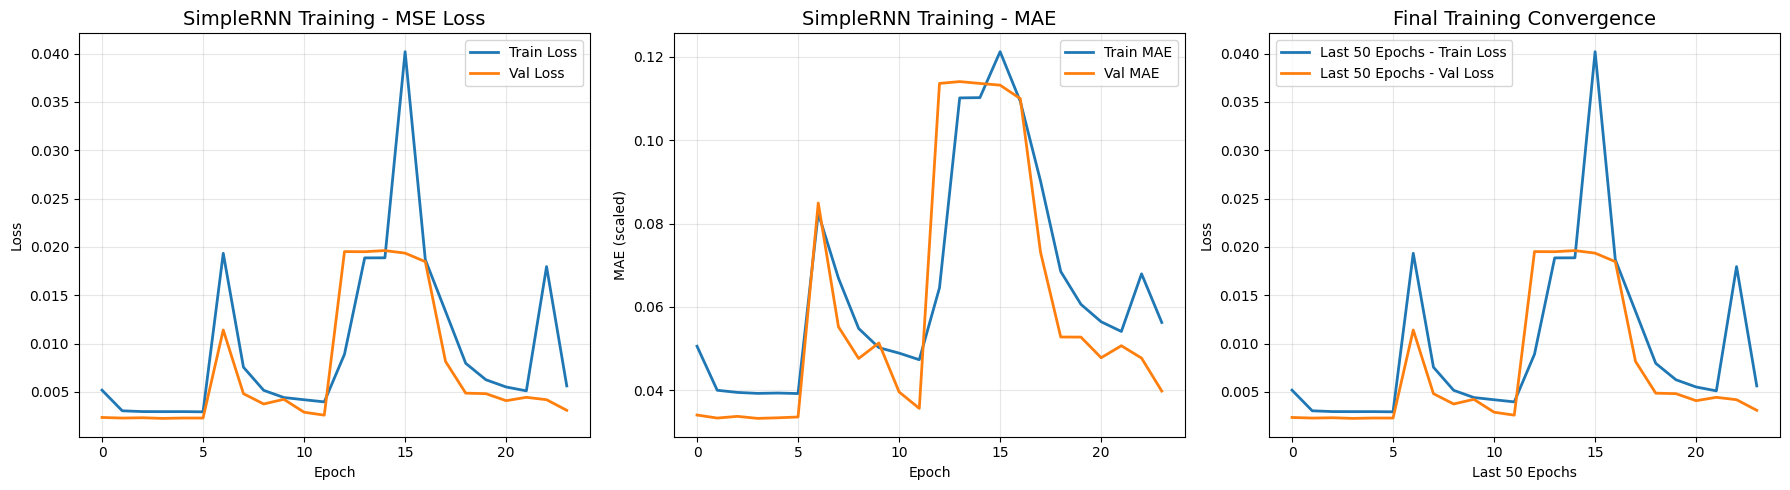

In [10]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('SimpleRNN Training - MSE Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_title('SimpleRNN Training - MAE', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate (if tracked)
if 'lr' in history.history:
    axes[2].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='purple')
    axes[2].set_title('Learning Rate Schedule', fontsize=14)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    # Show loss convergence instead
    axes[2].plot(history.history['loss'][-50:], label='Last 50 Epochs - Train Loss', linewidth=2)
    axes[2].plot(history.history['val_loss'][-50:], label='Last 50 Epochs - Val Loss', linewidth=2)
    axes[2].set_title('Final Training Convergence', fontsize=14)
    axes[2].set_xlabel('Last 50 Epochs')
    axes[2].set_ylabel('Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Predict on test set
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform function
def inverse_transform_sequence(y_scaled, scaler):
    y_scaled_flat = y_scaled.flatten().reshape(-1, 1)
    y_real = scaler.inverse_transform(y_scaled_flat)
    return y_real.reshape(y_scaled.shape)

# Inverse transform
y_pred = inverse_transform_sequence(y_pred_scaled, scaler)
y_real = inverse_transform_sequence(y_test, scaler)


Making predictions on test set...


In [12]:
# Calculate metrics for each prediction step
n_steps = y_real.shape[1]

print("\n" + "="*60)
print("SIMPLE RNN PREDICTION RESULTS - PATIENT LIB193263")
print("="*60)
print(f"Model: SimpleRNN (128 units) + Dense(32)")
print(f"Lookback: 48 timesteps, Horizon: {n_steps} steps")

metrics_by_horizon = []

for step in range(n_steps):
    time_minutes = 15 * (step + 1)

    rmse_step = np.sqrt(np.mean((y_real[:, step] - y_pred[:, step])**2))
    mae_step = np.mean(np.abs(y_real[:, step] - y_pred[:, step]))
    mape_step = np.mean(np.abs((y_real[:, step] - y_pred[:, step]) / (y_real[:, step] + 1e-8))) * 100
    accuracy_step = 100 - mape_step

    metrics_by_horizon.append({
        'time': time_minutes,
        'rmse': rmse_step,
        'mae': mae_step,
        'mape': mape_step,
        'accuracy': accuracy_step
    })

    print(f"\n{time_minutes}-min ahead prediction:")
    print(f"  RMSE : {rmse_step:.2f} mg/dL")
    print(f"  MAE  : {mae_step:.2f} mg/dL")
    print(f"  MAPE : {mape_step:.2f}%")
    print(f"  Accuracy: {accuracy_step:.2f}%")


SIMPLE RNN PREDICTION RESULTS - PATIENT LIB193263
Model: SimpleRNN (128 units) + Dense(32)
Lookback: 48 timesteps, Horizon: 4 steps

15-min ahead prediction:
  RMSE : 8.98 mg/dL
  MAE  : 6.67 mg/dL
  MAPE : 4.61%
  Accuracy: 95.39%

30-min ahead prediction:
  RMSE : 17.59 mg/dL
  MAE  : 12.96 mg/dL
  MAPE : 8.73%
  Accuracy: 91.27%

45-min ahead prediction:
  RMSE : 25.04 mg/dL
  MAE  : 18.53 mg/dL
  MAPE : 12.53%
  Accuracy: 87.47%

60-min ahead prediction:
  RMSE : 31.02 mg/dL
  MAE  : 23.19 mg/dL
  MAPE : 15.81%
  Accuracy: 84.19%


In [13]:
# Calculate overall metrics
overall_rmse = np.sqrt(np.mean((y_real - y_pred)**2))
overall_mae = np.mean(np.abs(y_real - y_pred))
overall_mape = np.mean(np.abs((y_real - y_pred) / (y_real + 1e-8))) * 100

print("\n" + "="*60)
print("OVERALL PERFORMANCE (all horizons):")
print("="*60)
print(f"Overall RMSE: {overall_rmse:.2f} mg/dL")
print(f"Overall MAE : {overall_mae:.2f} mg/dL")
print(f"Overall MAPE: {overall_mape:.2f}%")


OVERALL PERFORMANCE (all horizons):
Overall RMSE: 22.24 mg/dL
Overall MAE : 15.34 mg/dL
Overall MAPE: 10.42%


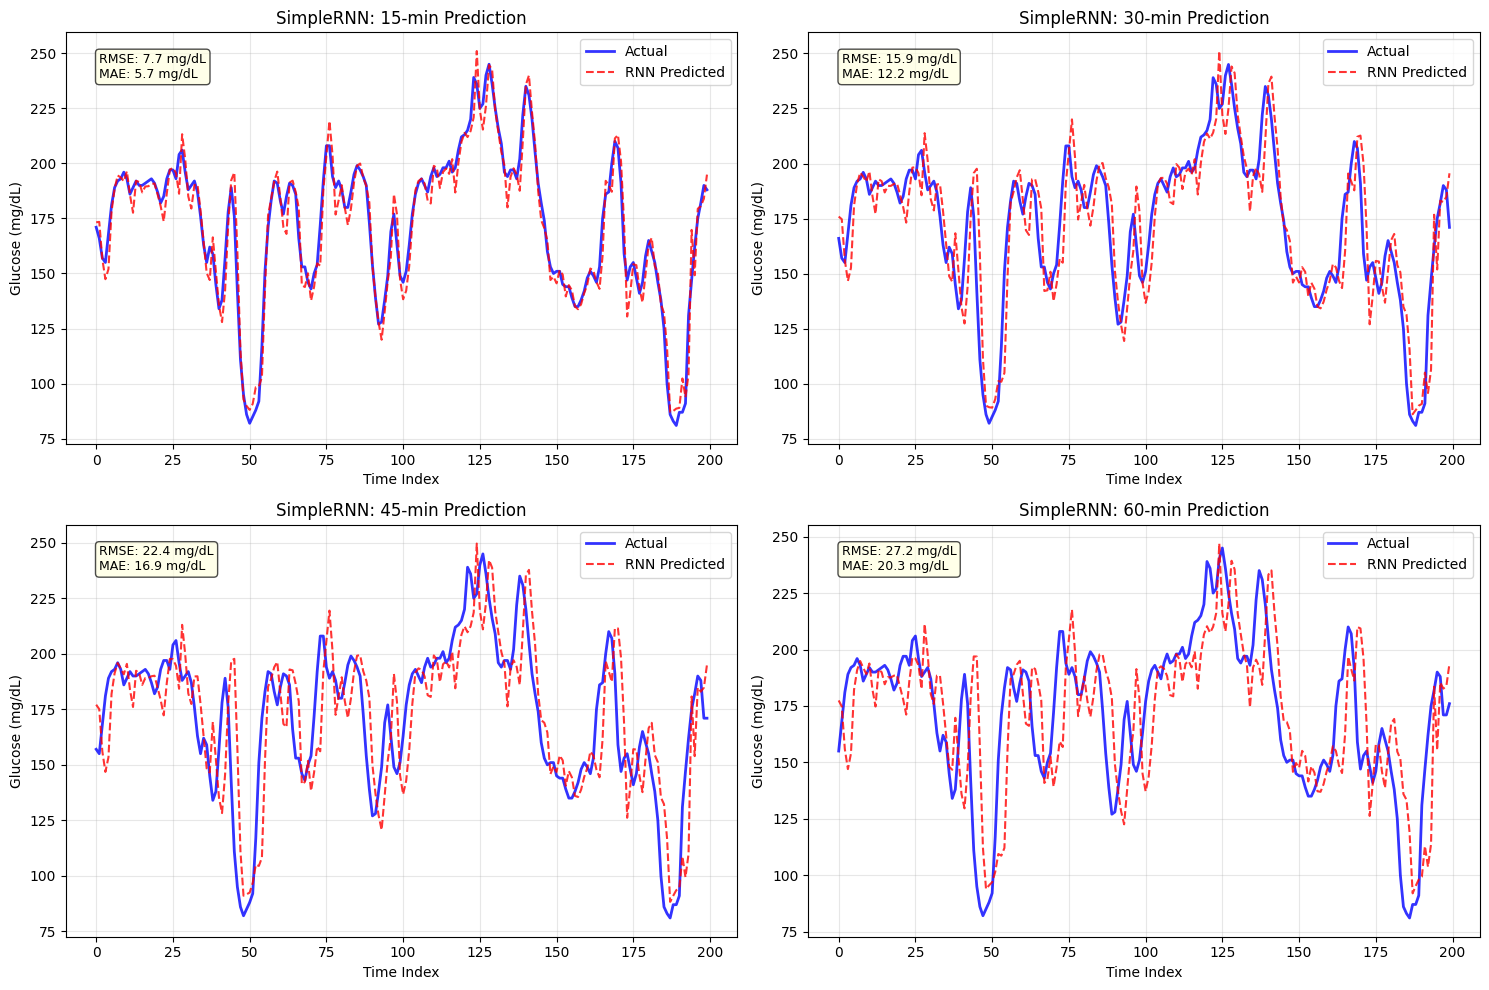

In [ ]:
# Plot predictions
n_plot = 200  # Show first 200 predictions

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

prediction_horizons = ['15-min', '30-min', '45-min', '60-min']

for step in range(n_steps):
    ax = axes[step]
    ax.plot(y_real[:n_plot, step], label='Actual', linewidth=2, alpha=0.8, color='blue')
    ax.plot(y_pred[:n_plot, step], label='RNN Predicted', linewidth=1.5, linestyle='--', alpha=0.8, color='red')
    ax.set_title(f'RNN: {prediction_horizons[step]} Prediction', fontsize=12)
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Glucose (mg/dL)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add metrics in text box
    rmse = np.sqrt(np.mean((y_real[:n_plot, step] - y_pred[:n_plot, step])**2))
    mae = np.mean(np.abs(y_real[:n_plot, step] - y_pred[:n_plot, step]))
    ax.text(0.05, 0.95, f'RMSE: {rmse:.1f} mg/dL\nMAE: {mae:.1f} mg/dL',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.savefig('rnn_predictions_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

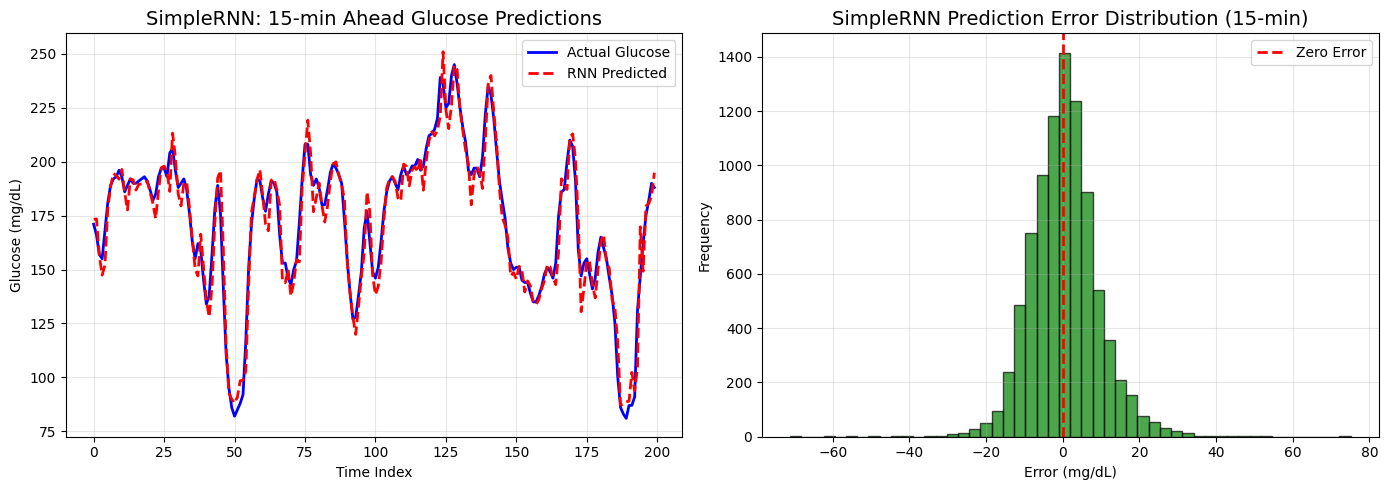

In [ ]:
# Create a combined plot for 15-min predictions only (most important)
plt.figure(figsize=(14, 5))

# Plot 1: Time series
plt.subplot(1, 2, 1)
plt.plot(y_real[:n_plot, 0], label='Actual Glucose', linewidth=2, color='blue')
plt.plot(y_pred[:n_plot, 0], label='RNN Predicted', linewidth=2, linestyle='--', color='red')
plt.title('RNN: 15-min Ahead Glucose Predictions', fontsize=14)
plt.xlabel('Time Index')
plt.ylabel('Glucose (mg/dL)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Error histogram
plt.subplot(1, 2, 2)
errors = y_real[:, 0] - y_pred[:, 0]
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='green')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.title('RNN Prediction Error Distribution (15-min)', fontsize=14)
plt.xlabel('Error (mg/dL)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rnn_15min_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Save predictions
np.save('rnn_predictions.npy', y_pred)
np.save('rnn_actuals.npy', y_real)

# Performance summary
print("\n" + "="*60)
print("RNN PERFORMANCE SUMMARY")
print("="*60)
print("\nHorizon | RMSE (mg/dL) | MAE (mg/dL) | MAPE (%) | Accuracy (%)")
print("-" * 65)

for i, metrics in enumerate(metrics_by_horizon):
    print(f"{metrics['time']:3d}-min | {metrics['rmse']:11.2f} | {metrics['mae']:10.2f} | "
          f"{metrics['mape']:7.2f} | {metrics['accuracy']:11.2f}")


SIMPLE RNN PERFORMANCE SUMMARY

Horizon | RMSE (mg/dL) | MAE (mg/dL) | MAPE (%) | Accuracy (%)
-----------------------------------------------------------------
 15-min |        8.98 |       6.67 |    4.61 |       95.39
 30-min |       17.59 |      12.96 |    8.73 |       91.27
 45-min |       25.04 |      18.53 |   12.53 |       87.47
 60-min |       31.02 |      23.19 |   15.81 |       84.19

RNN ARCHITECTURE NOTES:
✓ Vanilla/SimpleRNN (no gating mechanisms)
✓ 128 units with tanh activation
✓ Additional Dense(32) layer for feature learning
✓ Higher dropout (0.3) for regularization
✓ Larger batch size (32) for stability
✓ More training epochs (150) and patience (20)
✓ Expected: May underperform LSTM/GRU due to vanishing gradients

SAVED FILES:
1. Model: best_rnn_glucose_model.h5
2. Predictions: rnn_predictions.npy
3. Actuals: rnn_actuals.npy
4. Training history: rnn_training_history.png
5. Prediction plots: rnn_predictions_by_horizon.png
6. 15-min analysis: rnn_15min_analysis.png

Si